<a href="https://colab.research.google.com/github/renancotrin-alt/tech-challenge-fase-2-ibovespa/blob/V1_Ibovespa/notebooks/tech_challenge_fase_2_ibovespa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Tech Challenge Fase 2 - Previsao do Fechamento do IBOVESPA

Projeto desenvolvido para a Pos-Tech FIAP - Data Analytics.

O objetivo e construir uma estrategia de dados para prever diariamente o fechamento do IBOVESPA, usando dados historicos do Investing.com e demonstrando storytelling, decomposicao da serie temporal, explicacao do modelo, metricas estatisticas e previsao dos proximos 15 pregoes.

Como o enunciado fala em serie temporal e regressao, a metrica principal deste notebook e baseada em erro percentual: `assertividade = 1 - WMAPE`. Tambem usamos uma leitura complementar de acuracia por tolerancia: percentual de dias em que a previsao ficou dentro de uma margem de erro estatisticamente aceitavel.


## 1. Preparacao do ambiente


In [1]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/renancotrin-alt/tech-challenge-fase-2-ibovespa.git"
REPO_BRANCH = "V1_Ibovespa"
PROJECT_DIR = Path("tech-challenge-fase-2-ibovespa")

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    current_dir = Path.cwd()
    if current_dir.name != PROJECT_DIR.name:
        if not PROJECT_DIR.exists():
            subprocess.run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL], check=True)
        os.chdir(PROJECT_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    if Path.cwd().name == "notebooks":
        os.chdir("..")

print("Diretorio de trabalho:", Path.cwd())


Diretorio de trabalho: C:\Users\Renan\OneDrive\Documentos\Nova entrega Pos tech\tech-challenge-fase-2-ibovespa-revisao


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from src.data_prep import build_modeling_dataset, clean_ibovespa_data, load_raw_data, save_processed_dataset, temporal_train_test_split
from src.forecasting import REGRESSION_TARGET, evaluate_predictions, forecast_next_15_business_days, hit_rate, wmape
from src.modeling import FEATURE_COLUMNS, TARGET_COLUMN

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


Matplotlib is building the font cache; this may take a moment.


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Renan\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


## 2. Leitura e limpeza dos dados

A base bruta foi obtida no Investing.com e cobre o historico diario do IBOVESPA desde 2010. O arquivo original vem em ordem decrescente de data e usa formato brasileiro para numeros, percentuais e volume negociado. Por isso, a limpeza precisa tratar separadores decimais, unidades de volume (`K`, `M`, `B`) e a ordenacao cronologica antes de qualquer modelagem.


In [3]:
raw_df = load_raw_data()
dados = clean_ibovespa_data(raw_df)

print("Base bruta:", raw_df.shape)
print("Base limpa:", dados.shape)
print("Periodo:", dados["data"].min().date(), "a", dados["data"].max().date())
print("Volumes nulos apos limpeza:", int(dados["volume_num"].isna().sum()))
display(dados.head())
display(dados.tail())


Base bruta: (4110, 7)
Base limpa: (4110, 8)
Periodo: 2010-01-04 a 2026-07-29
Volumes nulos apos limpeza: 1


,data,fechamento,abertura,maxima,minima,volume,variacao_pct,volume_num
0,2010-01-04,70045.0,68587.0,70081.0,68587.0,"1,66M",0.0212,1660000.0
1,2010-01-05,70240.0,70046.0,70595.0,69928.0,"1,98M",0.0028,1980000.0
2,2010-01-06,70729.0,70236.0,70937.0,70016.0,"2,24M",0.0070,2240000.0
3,2010-01-07,70451.0,70723.0,70723.0,70045.0,"1,55M",-0.0039,1550000.0
4,2010-01-08,70263.0,70455.0,70766.0,70158.0,"1,63M",-0.0027,1630000.0


,data,fechamento,abertura,maxima,minima,volume,variacao_pct,volume_num
4105,2026-07-23,176724.0,177546.0,177896.0,176293.0,"6,35B",-0.0046,6.350000e+09
4106,2026-07-24,174042.0,176720.0,176720.0,174042.0,"5,42B",-0.0152,5.420000e+09
4107,2026-07-27,175334.0,174048.0,175555.0,174048.0,"5,84B",0.0074,5.840000e+09
4108,2026-07-28,176565.0,175326.0,178539.0,175326.0,"6,74B",0.0070,6.740000e+09
4109,2026-07-29,173885.0,176564.0,176564.0,173885.0,"7,34B",-0.0152,7.340000e+09


## 3. Storytelling e analise exploratoria

Antes dos modelos, vale olhar para o comportamento da serie. O IBOVESPA nao apresenta um padrao sazonal simples; ele muda de regime conforme ciclos economicos, juros, fluxo estrangeiro, eventos politicos e choques globais. Essa leitura e importante porque ajuda a explicar por que modelos de curto prazo devem ser reavaliados periodicamente.


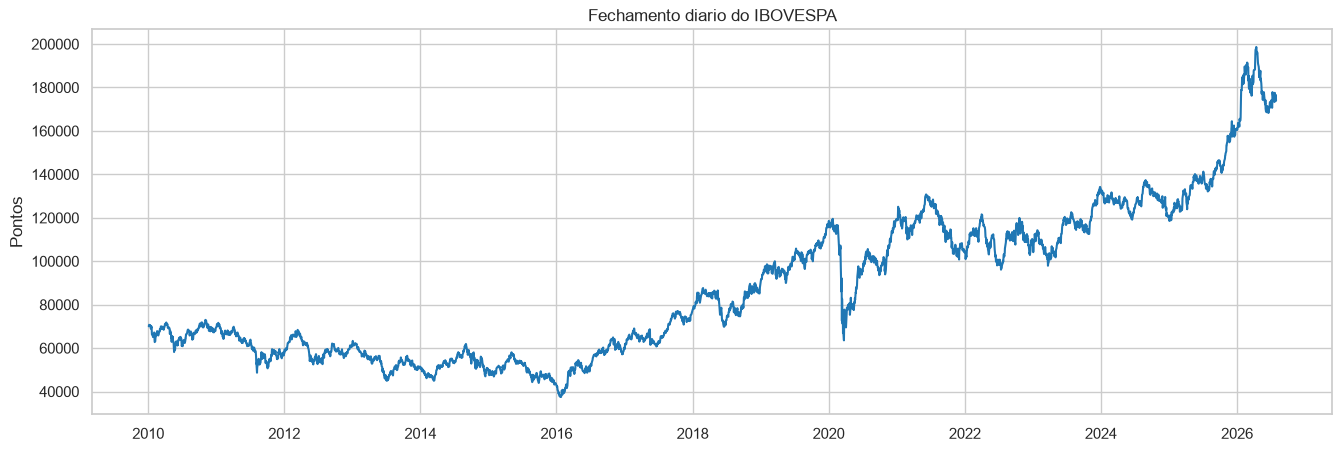

In [4]:
fig, ax = plt.subplots(figsize=(16, 5))
sns.lineplot(data=dados, x="data", y="fechamento", ax=ax, color="#1f77b4")
ax.set_title("Fechamento diario do IBOVESPA")
ax.set_xlabel("")
ax.set_ylabel("Pontos")
plt.show()


Leitura dos principais ciclos:

- 2010 a 2015: periodo de desempenho fraco, com desaceleracao economica, pressao fiscal e perda de confianca.
- 2015 a 2016: ponto de maior estresse politico e economico, associado a recessao e impeachment.
- 2016 a 2020: recuperacao forte, com expectativa de reformas e juros mais baixos.
- 2020: choque da pandemia, com quedas e altas extremas em poucos dias.
- 2021 a 2022: aperto monetario e incerteza eleitoral.
- 2023 a 2026: novo ciclo de alta, com corte de juros, resultados corporativos e fluxo para bolsa.


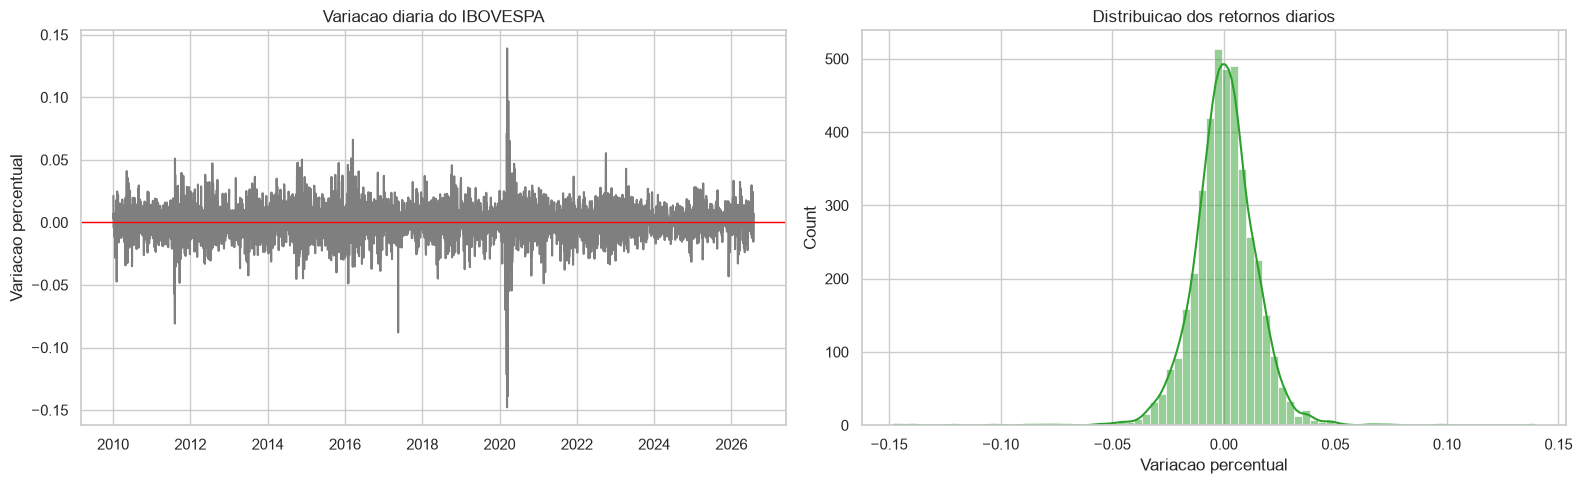

Maiores altas diarias:


,data,fechamento,variacao_pct
2521,2020-03-13,82678.0,0.1391
2528,2020-03-24,69729.0,0.0969
2529,2020-03-25,74956.0,0.0750
2518,2020-03-10,92214.0,0.0714
1534,2016-03-17,50914.0,0.0660


Maiores quedas diarias:


,data,fechamento,variacao_pct
2520,2020-03-12,72583.0,-0.1478
2522,2020-03-16,71168.0,-0.1392
2517,2020-03-09,86067.0,-0.1217
2524,2020-03-18,66895.0,-0.1035
1825,2017-05-18,61597.0,-0.0880


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=dados, x="data", y="variacao_pct", ax=axes[0], color="#7f7f7f")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Variacao diaria do IBOVESPA")
axes[0].set_xlabel("")
axes[0].set_ylabel("Variacao percentual")

sns.histplot(dados["variacao_pct"], bins=80, kde=True, ax=axes[1], color="#2ca02c")
axes[1].set_title("Distribuicao dos retornos diarios")
axes[1].set_xlabel("Variacao percentual")
plt.tight_layout()
plt.show()

picos_alta = dados.nlargest(5, "variacao_pct")[["data", "fechamento", "variacao_pct"]]
picos_baixa = dados.nsmallest(5, "variacao_pct")[["data", "fechamento", "variacao_pct"]]
print("Maiores altas diarias:")
display(picos_alta)
print("Maiores quedas diarias:")
display(picos_baixa)


Os picos de volatilidade se concentram em momentos de choque, principalmente em 2020. Para a metrica de acuracia por tolerancia, usaremos uma margem de 2,15%, proxima de um patamar alto, mas ainda plausivel, da variacao diaria historica do indice.


In [6]:
ret_abs = dados["variacao_pct"].abs().dropna()
vol_summary = pd.Series({
    "media_abs": ret_abs.mean(),
    "media_mais_1_desvio": ret_abs.mean() + ret_abs.std(),
    "p90_abs": ret_abs.quantile(0.90),
    "p95_abs": ret_abs.quantile(0.95),
})
display((vol_summary * 100).round(2).rename("valor_em_pct"))


media_abs              1.04
media_mais_1_desvio    2.05
p90_abs                2.20
p95_abs                2.73
Name: valor_em_pct, dtype: float64

## 4. Decomposicao da serie temporal

A decomposicao separa a serie em tendencia, sazonalidade e residuo. Como a bolsa negocia apenas em dias uteis e tambem possui feriados, criamos uma serie diaria preenchida por `ffill` somente para esta analise visual. Os modelos preditivos continuam usando apenas os pregoes reais.


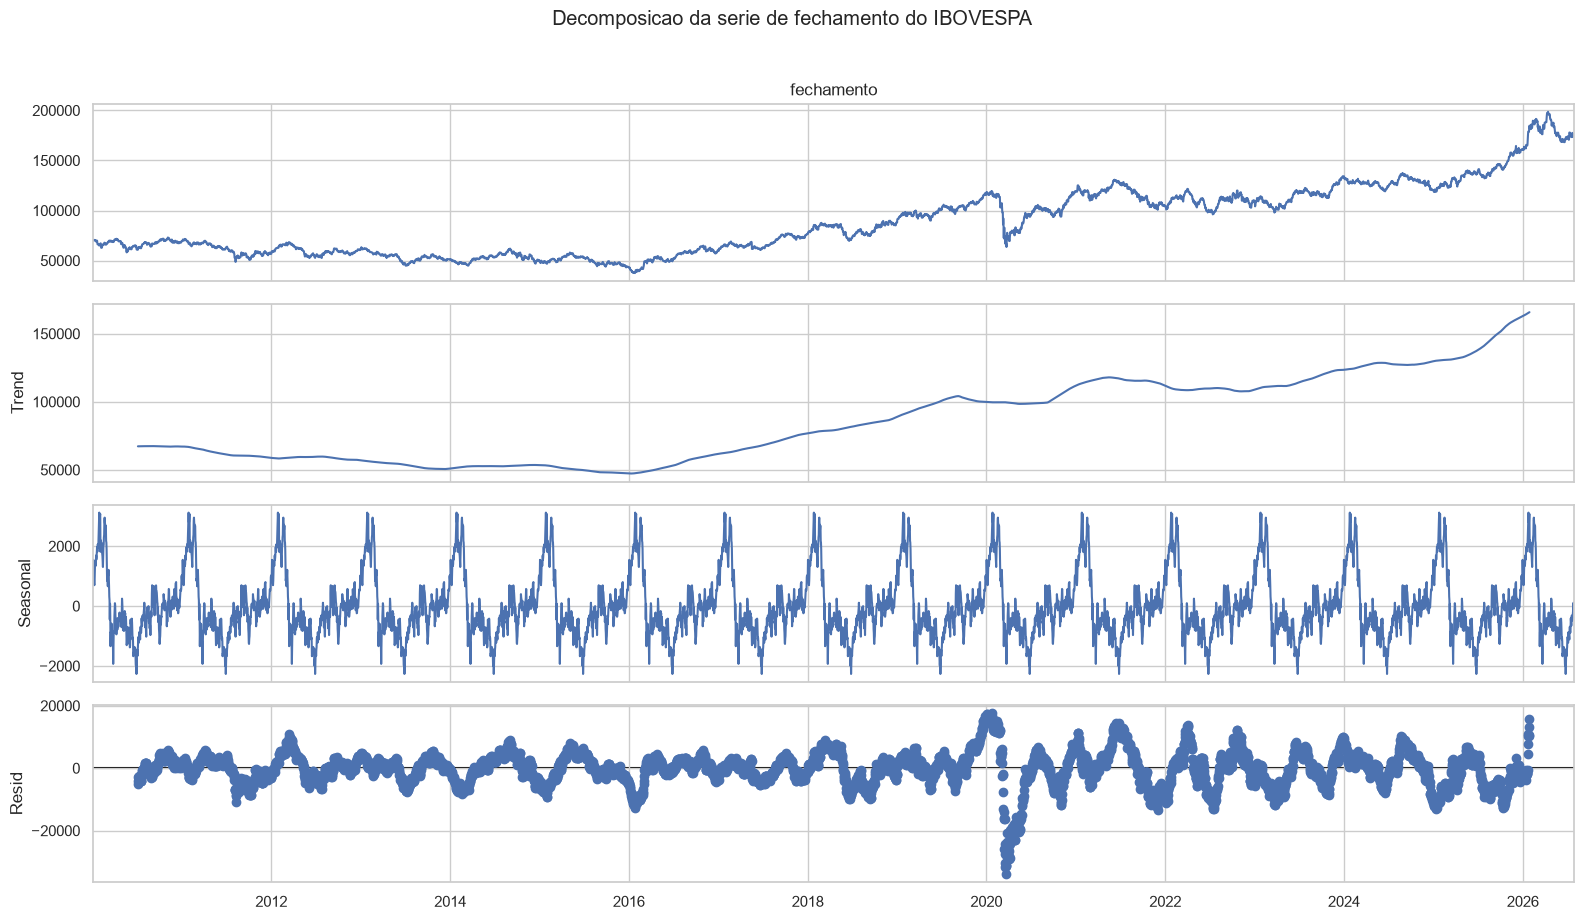

In [7]:
serie_diaria = dados[["data", "fechamento"]].set_index("data").asfreq("D").ffill()
decomposicao = seasonal_decompose(serie_diaria["fechamento"], model="additive", period=365)

fig = decomposicao.plot()
fig.set_size_inches(16, 9)
fig.suptitle("Decomposicao da serie de fechamento do IBOVESPA", y=1.02)
plt.tight_layout()
plt.show()


A decomposicao confirma que a serie e dominada por tendencia e choques de residuo. A sazonalidade anual aparece matematicamente, mas nao e o componente mais relevante para explicar a bolsa. Isso favorece modelos autorregressivos simples, como ARIMA, em vez de modelos sazonais pesados.


## 5. Estacionariedade, ADF, ACF e PACF

O ARIMA exige uma decisao sobre a ordem de diferenciacao. Para isso usamos o teste ADF. A hipotese nula e que a serie nao e estacionaria; portanto, p-valor alto na serie original e p-valor baixo na primeira diferenca sustentam o uso de `d=1`.


In [8]:
adf_original = adfuller(dados["fechamento"])
adf_diff = adfuller(dados["fechamento"].diff().dropna())

print("ADF - serie original")
print(f"Estatistica: {adf_original[0]:.4f}")
print(f"P-valor: {adf_original[1]:.4f}")
print("Resultado:", "nao estacionaria" if adf_original[1] > 0.05 else "estacionaria")

print("\nADF - primeira diferenca")
print(f"Estatistica: {adf_diff[0]:.4f}")
print(f"P-valor: {adf_diff[1]:.8f}")
print("Resultado:", "nao estacionaria" if adf_diff[1] > 0.05 else "estacionaria")


ADF - serie original
Estatistica: -0.1526
P-valor: 0.9439
Resultado: nao estacionaria

ADF - primeira diferenca
Estatistica: -17.0261
P-valor: 0.00000000
Resultado: estacionaria


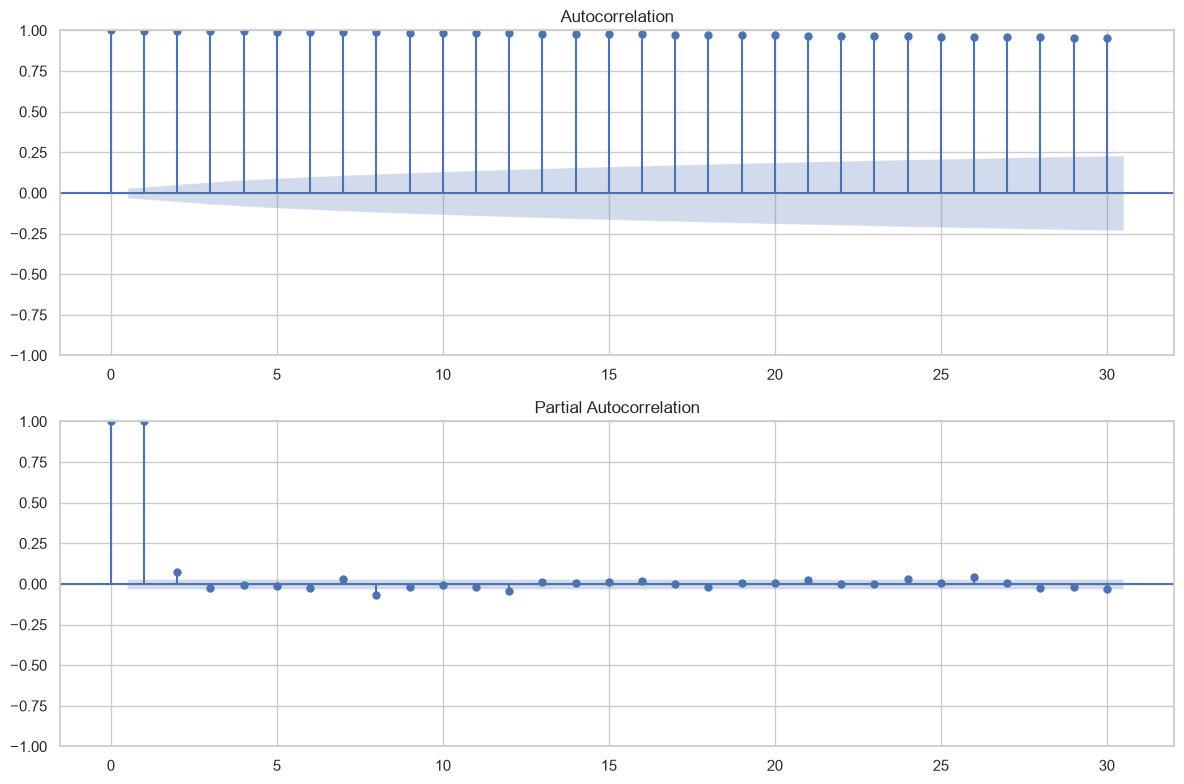

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(dados["fechamento"], lags=30, ax=axes[0])
plot_pacf(dados["fechamento"], lags=30, ax=axes[1], method="ols")
plt.tight_layout()
plt.show()


A primeira diferenca estacionaria justifica `d=1`. A autocorrelacao de curto prazo sustenta testar um ARIMA com componente autorregressivo, usando `ARIMA(5,1,0)` como modelo principal.


## 6. Separacao temporal de treino e teste

Em series temporais, o split nao pode ser aleatorio. Usamos os ultimos 125 pregoes como teste, aproximadamente seis meses de mercado recente. Essa janela simula um periodo fora da amostra, sem vazamento de futuro.


In [10]:
reg_df = dados.copy()
reg_df[REGRESSION_TARGET] = reg_df["fechamento"].shift(-1)
reg_df["data_alvo"] = reg_df["data"].shift(-1)
reg_df = reg_df.dropna(subset=[REGRESSION_TARGET]).reset_index(drop=True)

N_TEST = 125
train_reg = reg_df.iloc[:-N_TEST].copy()
test_reg = reg_df.iloc[-N_TEST:].copy()
y_true = test_reg[REGRESSION_TARGET].values

print("Base de regressao:", reg_df.shape)
print("Treino:", train_reg["data"].min().date(), "a", train_reg["data"].max().date(), len(train_reg), "pregoes")
print("Teste (datas-alvo):", test_reg["data_alvo"].min().date(), "a", test_reg["data_alvo"].max().date(), len(test_reg), "pregoes")


Base de regressao: (4109, 10)
Treino: 2010-01-04 a 2026-01-26 3984 pregoes
Teste (datas-alvo): 2026-01-28 a 2026-07-29 125 pregoes


## 7. Modelos de regressao e metrica de assertividade

A metrica principal e WMAPE, uma versao ponderada do erro percentual absoluto. Como o enunciado pede assertividade, reportamos `1 - WMAPE`. Tambem reportamos MAE em pontos e acerto dentro da tolerancia de 2,15%.


In [11]:
naive_pred = test_reg["fechamento"].values
naive_result = evaluate_predictions("Naive - persistencia", y_true, naive_pred)

static_history = pd.concat([train_reg, test_reg.iloc[[0]]], ignore_index=True)
arima_static = ARIMA(static_history["fechamento"].values, order=(5, 1, 0)).fit()
pred_static = np.asarray(arima_static.forecast(steps=len(test_reg)), dtype=float)
static_result = evaluate_predictions("ARIMA(5,1,0) estatico", y_true, pred_static)

history = list(train_reg["fechamento"].values)
preds_wf = []
for fechamento_real in test_reg["fechamento"].values:
    history.append(fechamento_real)
    model = ARIMA(history, order=(5, 1, 0)).fit()
    preds_wf.append(float(model.forecast(steps=1)[0]))
preds_wf = np.array(preds_wf)
walk_result = evaluate_predictions("ARIMA(5,1,0) walk-forward", y_true, preds_wf)

results_reg = pd.DataFrame([
    naive_result.__dict__,
    static_result.__dict__,
    walk_result.__dict__,
])
results_reg = results_reg.rename(columns={"hit_rate_0215": "acerto_tolerancia_2_15"})
display(results_reg.style.format({
    "wmape": "{:.2%}",
    "assertiveness": "{:.2%}",
    "mae": "{:,.0f}",
    "acerto_tolerancia_2_15": "{:.2%}",
}))


,name,wmape,assertiveness,mae,acerto_tolerancia_2_15
0,Naive - persistencia,0.93%,99.07%,"1,678",91.20%
1,"ARIMA(5,1,0) estatico",3.75%,96.25%,"6,787",28.00%
2,"ARIMA(5,1,0) walk-forward",0.93%,99.07%,"1,681",92.00%


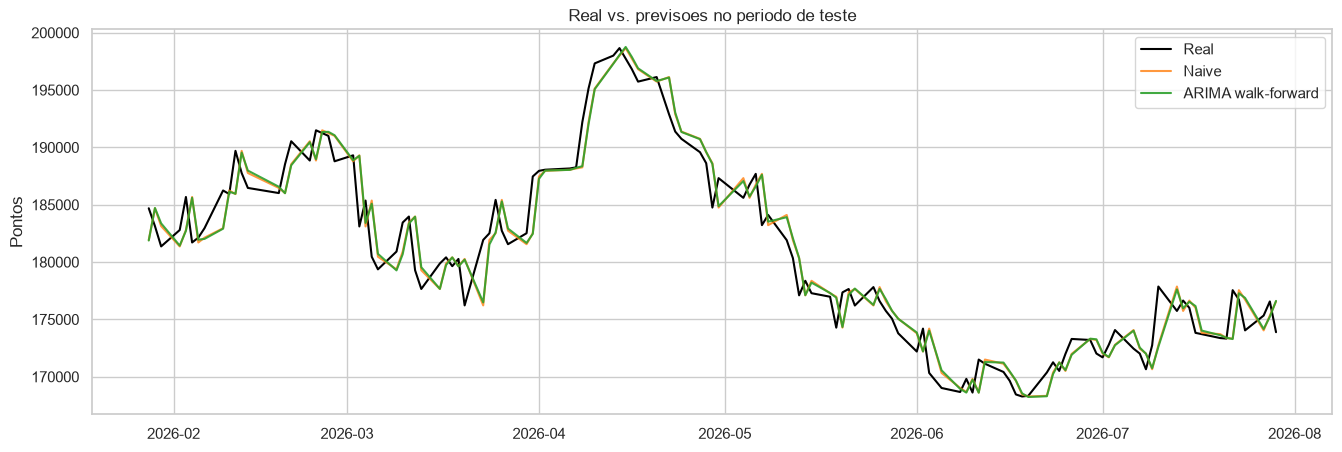

In [12]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_reg["data_alvo"], y_true, label="Real", color="black")
ax.plot(test_reg["data_alvo"], naive_pred, label="Naive", color="#ff7f0e", alpha=0.8)
ax.plot(test_reg["data_alvo"], preds_wf, label="ARIMA walk-forward", color="#2ca02c", alpha=0.9)
ax.set_title("Real vs. previsoes no periodo de teste")
ax.set_xlabel("")
ax.set_ylabel("Pontos")
ax.legend()
plt.show()


O ARIMA walk-forward atinge a meta de 80% com folga pela leitura `1 - WMAPE` e tambem supera 80% na metrica de tolerancia de 2,15%. O baseline Naive deve permanecer na analise porque ele mostra uma caracteristica importante da serie: como o fechamento de amanha costuma estar perto do fechamento de hoje, repetir o ultimo valor ja gera erro percentual baixo. O ARIMA foi escolhido por dar uma estrutura estatistica auditavel a esse comportamento e permitir extensoes futuras, como SARIMAX com variaveis externas.


## 8. Regressao com features tecnicas

Como contraponto ao ARIMA, testamos modelos de regressao com features tecnicas. Eles usam retornos, medias moveis, volatilidade, volume e indicadores como RSI, MACD e Bollinger. O objetivo e verificar se esses atributos conseguem reduzir o erro alem do comportamento de persistencia.


In [13]:
model_df = build_modeling_dataset()
train_feat, test_feat = temporal_train_test_split(model_df, test_size=N_TEST)

x_train = train_feat[FEATURE_COLUMNS]
y_train = train_feat["fechamento_amanha"]
x_test = test_feat[FEATURE_COLUMNS]
y_test_reg = test_feat["fechamento_amanha"]

lin_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
lin_reg.fit(x_train, y_train)
lin_pred = lin_reg.predict(x_test)

rf_reg = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=10, random_state=42, n_jobs=-1)
rf_reg.fit(x_train, y_train)
rf_pred = rf_reg.predict(x_test)

feature_results = pd.DataFrame([
    evaluate_predictions("Linear Regression - features", y_test_reg, lin_pred).__dict__,
    evaluate_predictions("Random Forest - features", y_test_reg, rf_pred).__dict__,
])
feature_results = feature_results.rename(columns={"hit_rate_0215": "acerto_tolerancia_2_15"})
display(feature_results.style.format({
    "wmape": "{:.2%}",
    "assertiveness": "{:.2%}",
    "mae": "{:,.0f}",
    "acerto_tolerancia_2_15": "{:.2%}",
}))


,name,wmape,assertiveness,mae,acerto_tolerancia_2_15
0,Linear Regression - features,0.95%,99.05%,"1,712",91.20%
1,Random Forest - features,7.36%,92.64%,"13,302",12.00%


Os modelos com features ajudam a testar alternativas, mas o resultado central continua sendo o ARIMA walk-forward. Essa comparacao e util porque evita escolher um modelo sem baseline e mostra que, para fechamento diario, persistencia e autocorrelacao curta explicam grande parte da previsao.


## 9. Classificacao de direcao como analise complementar

A previsao de fechamento resolve a meta formal de assertividade. Ainda assim, a pergunta de direcao - alta ou baixa no proximo pregao - e relevante para investidores. Por isso mantemos uma investigacao complementar, reportando os limites da tarefa de forma transparente.


In [14]:
x_train_cls = train_feat[FEATURE_COLUMNS]
y_train_cls = train_feat[TARGET_COLUMN]
x_test_cls = test_feat[FEATURE_COLUMNS]
y_test_cls = test_feat[TARGET_COLUMN]

classifiers = {
    "Baseline - classe majoritaria": None,
    "Regressao Logistica": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=20, random_state=42, n_jobs=-1),
    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(C=0.8, kernel="rbf", class_weight="balanced", random_state=42)),
    ]),
}

cls_rows = []
cls_predictions = {}
majority = int(y_train_cls.mode().iloc[0])
for name, clf in classifiers.items():
    if clf is None:
        pred = np.full(len(y_test_cls), majority)
    else:
        clf.fit(x_train_cls, y_train_cls)
        pred = clf.predict(x_test_cls)
    cls_predictions[name] = pred
    cm = confusion_matrix(y_test_cls, pred, labels=[0, 1])
    cls_rows.append({
        "modelo": name,
        "acuracia": accuracy_score(y_test_cls, pred),
        "tn_baixa_correta": cm[0, 0],
        "fp_alta_errada": cm[0, 1],
        "fn_baixa_errada": cm[1, 0],
        "tp_alta_correta": cm[1, 1],
    })

cls_results = pd.DataFrame(cls_rows).sort_values("acuracia", ascending=False)
display(cls_results.style.format({"acuracia": "{:.2%}"}))


,modelo,acuracia,tn_baixa_correta,fp_alta_errada,fn_baixa_errada,tp_alta_correta
3,SVC,47.20%,2,66,0,57
1,Regressao Logistica,46.40%,21,47,20,37
0,Baseline - classe majoritaria,45.60%,0,68,0,57
2,Random Forest,45.60%,0,68,0,57


Melhor classificador: SVC
              precision    recall  f1-score   support

 Baixa/igual       1.00      0.03      0.06        68
        Alta       0.46      1.00      0.63        57

    accuracy                           0.47       125
   macro avg       0.73      0.51      0.35       125
weighted avg       0.76      0.47      0.32       125



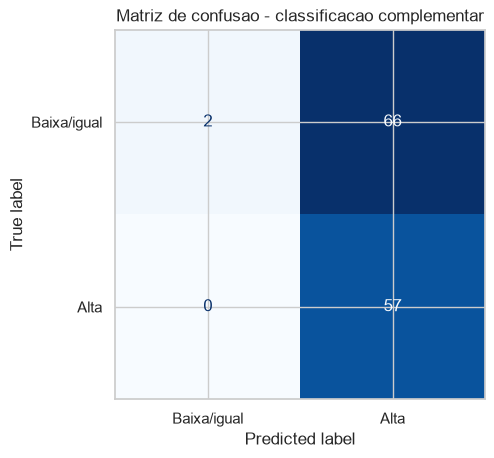

In [15]:
best_cls = cls_results.iloc[0]["modelo"]
best_pred = cls_predictions[best_cls]
print("Melhor classificador:", best_cls)
print(classification_report(y_test_cls, best_pred, target_names=["Baixa/igual", "Alta"], zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    best_pred,
    display_labels=["Baixa/igual", "Alta"],
    cmap="Blues",
    colorbar=False,
)
plt.title("Matriz de confusao - classificacao complementar")
plt.show()


A classificacao de direcao nao e usada como metrica principal da entrega porque e uma tarefa mais instavel e proxima de ruido de mercado. Reportar esse limite fortalece a analise: o projeto atinge a meta por regressao, mas nao promete uma capacidade artificial de acertar compra/venda diariamente.


## 10. Predicao dos proximos 15 pregoes

Com o modelo definido, treinamos o ARIMA(5,1,0) com todo o historico disponivel e projetamos 15 dias uteis a frente. O intervalo de confianca de 95% e tao importante quanto a previsao pontual, porque mostra como a incerteza cresce com o horizonte.


In [16]:
previsao_15d = forecast_next_15_business_days()
previsao_formatada = previsao_15d.copy()
for col in ["fechamento_previsto", "ic_inferior_95", "ic_superior_95"]:
    previsao_formatada[col] = previsao_formatada[col].round(0).astype(int)
display(previsao_formatada)


,data,fechamento_previsto,ic_inferior_95,ic_superior_95
0,2026-07-30,174023,171617,176430
1,2026-07-31,173911,170598,177225
2,2026-08-03,173947,169889,178005
3,2026-08-04,173946,169258,178634
4,2026-08-05,173892,168641,179143
5,2026-08-06,173897,168117,179677
6,2026-08-07,173893,167630,180156
7,2026-08-10,173894,167182,180606
8,2026-08-11,173894,166761,181027
9,2026-08-12,173893,166362,181423


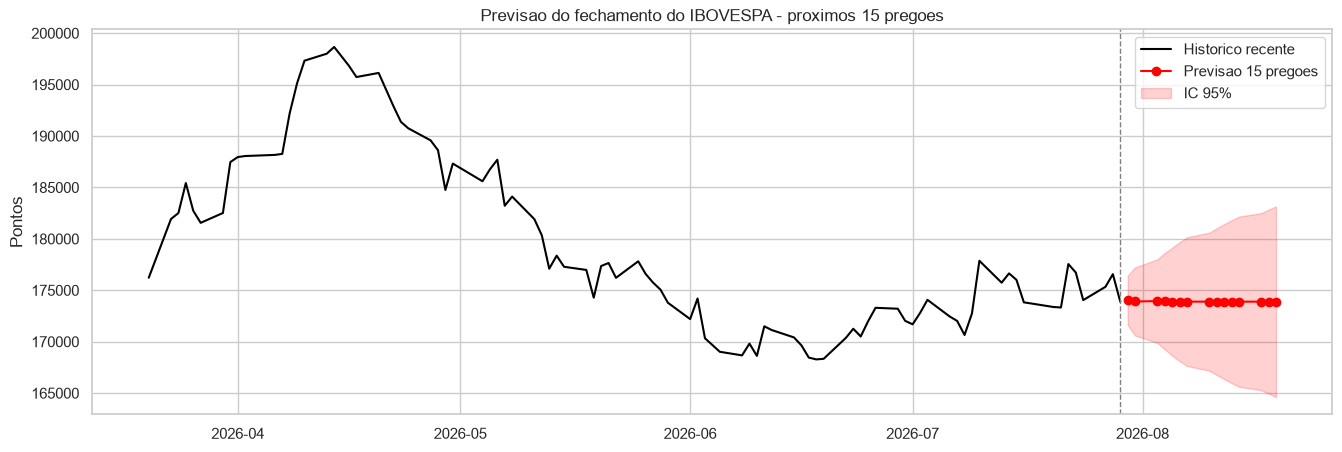

Ultimo fechamento real: 2026-07-29 173,885 pontos
Previsao no 15o pregao: 2026-08-19 173,893 pontos


In [17]:
fig, ax = plt.subplots(figsize=(16, 5))
historico_recente = dados.tail(90)
ax.plot(historico_recente["data"], historico_recente["fechamento"], label="Historico recente", color="black")
ax.plot(previsao_15d["data"], previsao_15d["fechamento_previsto"], label="Previsao 15 pregoes", color="red", marker="o")
ax.fill_between(
    previsao_15d["data"],
    previsao_15d["ic_inferior_95"],
    previsao_15d["ic_superior_95"],
    color="red",
    alpha=0.18,
    label="IC 95%",
)
ax.axvline(dados["data"].max(), color="gray", linestyle="--", linewidth=1)
ax.set_title("Previsao do fechamento do IBOVESPA - proximos 15 pregoes")
ax.set_xlabel("")
ax.set_ylabel("Pontos")
ax.legend()
plt.show()

print("Ultimo fechamento real:", dados["data"].max().date(), f"{dados['fechamento'].iloc[-1]:,.0f} pontos")
print("Previsao no 15o pregao:", previsao_15d["data"].iloc[-1].date(), f"{previsao_15d['fechamento_previsto'].iloc[-1]:,.0f} pontos")


## 11. Conclusao

A entrega principal e um modelo de serie temporal para prever o fechamento diario do IBOVESPA. O ARIMA(5,1,0) walk-forward atinge a meta de assertividade por WMAPE e tambem fica acima de 80% na leitura de tolerancia de 2,15% no periodo de teste.

O resultado deve ser interpretado como apoio analitico. A previsao numerica de fechamento e mais estavel do que a direcao diaria, mas ainda assim depende de atualizacao frequente e nao substitui analise macroeconomica, gestao de risco e acompanhamento de eventos externos. Como proximos passos, a evolucao natural seria testar SARIMAX com variaveis exogenas, como Selic, cambio, S&P 500, VIX, commodities e indicadores de fluxo.
